# CSED 504 — A1: A second data source — CIFAR-100 from the HuggingFace Hub

Part 1's study (`../README.md`) made two claims we can test further:

1. **The models port across datasets unchanged** — the same four architectures ran on CIFAR-10
   and ImageNet-32 with only `num_classes` moving.  This notebook adds a third dataset and
   imports `../a1-imagenet32/models.py` **without touching it**.
2. **Data scale decides CNN vs ViT** — CNN ahead by 19.5 points at 50k images, ViT ahead by
   1.2 at 1.28M.  But which scale?  *Total images* or *images per class*?
   CIFAR-100 splits those variables: it has the **same 50k images as CIFAR-10 but 100 classes**
   — 500 images per class instead of 5,000.

   | dataset | images | imgs/class | CNN − ViT gap |
   |---|---|---|---|
   | CIFAR-10 | 50k | 5,000 | **+19.5** (CNN ahead) |
   | ImageNet-32 | 1.28M | 1,281 | **−1.2** (ViT ahead) |
   | CIFAR-100 | 50k | 500 | **← this notebook measures it** |

   If total data drives the gap, CIFAR-100 should look like CIFAR-10.  If per-class data is
   what the ViT is starved of, the gap should get even wider here.

It also completes the proposal's data-requirements goal: *"adapt to HuggingFace data,
evaluating different data sources."*  The data comes from the **HuggingFace Hub**
(`uoft-cs/cifar100`, parquet) instead of torchvision's binary download — the same acquisition
path part 2 will use — and flows through a ~15-line wrapper into the exact same training loop.

---
**Google Colab:** open this notebook from GitHub (**File → Open notebook → GitHub**, pick the
branch), set **Runtime → Change runtime type → GPU**, and **Run all** — the first cell clones
the repo automatically.  No account or token needed; the dataset is public.

In [1]:
# -- Colab bootstrap ------------------------------------------------------------------------------
# On Google Colab this clones the repo and moves into src/a1-cv, so ../common and
# ../a1-imagenet32 import exactly like they do locally.  A no-op everywhere else.
import os, sys

if 'google.colab' in sys.modules and not os.path.isdir('../common'):
    REPO   = 'https://github.com/NahomAzmach/WashingtonCsed504.git'   # -> team repo after merge
    BRANCH = 'nazmach/cifar100-hf'                                    # -> 'main' after merge
    !git clone --quiet --branch {BRANCH} {REPO}
    %cd WashingtonCsed504/src/a1-cv
    print('Colab setup complete:', os.getcwd())

In [2]:
# Install required packages.  A no-op in the uw-csed504 conda environment; on Colab this only
# adds `datasets` (everything else is preinstalled).
%pip install --quiet torch torchvision numpy matplotlib tqdm datasets

Note: you may need to restart the kernel to use updated packages.


In [3]:
# -- Path setup + device detection ------------------------------------------------------------------
# ../common        -> gpu_check.py (device detection + seeds), same as every other notebook
# ../a1-imagenet32 -> models.py, imported UNCHANGED — that's claim 1 of this notebook

import os, sys

for rel in ('../common', '../a1-imagenet32'):
    p = os.path.normpath(os.path.join(os.getcwd(), rel))
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)

from gpu_check import get_device, set_seed
DEVICE = get_device()

# Parallel-experiment switch: on a multi-GPU box, set RUN_GPU=0/1 (and MODEL) in the environment
# before launching the kernel to pin this run to ONE card, so resnet18 and vit can train at the
# same time — one per GPU.  A no-op on single-GPU machines and Colab.  (DataParallel is NOT used:
# it measured ~1.0x at this model scale — the second card is worth more as a second experiment.)
import torch
if torch.cuda.is_available() and torch.cuda.device_count() > 1 and os.environ.get('RUN_GPU'):
    _g = int(os.environ['RUN_GPU'])
    torch.cuda.set_device(_g)
    DEVICE = torch.device(f'cuda:{_g}')
    print(f'  Pinned to cuda:{_g} (RUN_GPU={_g}) for a parallel per-card run')

set_seed(42)

try:
    from gpu_check import enable_fast_matmul
    enable_fast_matmul()          # TF32 + cuDNN autotune on NVIDIA; harmless elsewhere
except Exception:
    pass

  PyTorch  : 2.11.0+cu128
  CUDA     : 12.8
  Device   : cuda  [2 GPUs visible - CUDA_VISIBLE_DEVICES='GPU-b09775ec-7817-5003-b4ac-cc406fac5a51,GPU-5b633072-72ed-f715-70ab-c3b32cba0178']
    cuda:0  NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition  sm_120  102.6 GB  <- cuda:0 (primary)
    cuda:1  NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition  sm_120  102.6 GB
  Multi-GPU (2 cards) - pick by goal:
    - FASTER inner loop: stay on ONE card + enable_fast_matmul() + bf16 autocast. DataParallel rarely helps at class model scale
      (comms overhead cancels the 2nd card); measure before relying on it.
    - MORE experiments at once: launch a separate run per card
    - BIGGER model (won't fit on 1 card): device_map="auto", max_memory=get_max_memory()
  Pinned to cuda:0 (RUN_GPU=0) for a parallel per-card run


## 1. Configuration

`MODEL` picks the architecture (both come from `a1-imagenet32/models.py`), and the right
training recipe follows automatically — the part-1 lesson that a ViT under a CNN recipe loses
~18 points is baked in here.

| machine | SUBSET_PER_CLASS | EPOCHS | time |
|---|---|---|---|
| CPU-only laptop (pipeline check only) | 10 (= 1k imgs) | 1 | ~15–20 min (measured on a 4-core Intel Mac — Colab is honestly the better idea) |
| Colab T4 | None (all 50k) | 40 | ~30–40 min |
| workstation GPU | None | 60 | ~15 min |

The **test set always stays the full 10k** so accuracy is honest and comparable.
Run the notebook twice — once with `MODEL='resnet18'`, once with `MODEL='vit'` — to measure
the gap.

In [4]:
MODEL            = os.environ.get('MODEL', 'resnet18')   # 'resnet18' | 'vit' (also 'resnet50' | 'vit_base')
EPOCHS           = 40                                     # env override lets two kernels run different models
BATCH_SIZE       = 512           # 512, not 128: with data+aug on the GPU (§2) batch size is the throughput
SUBSET_PER_CLASS = None          #   lever for a small net on this card — bs128 is launch-bound (~13k img/s),
NUM_CLASSES      = 100           #   bs512 hits ~21k at high utilization.  None = full train set.

# Recipe follows the architecture (part 1, section 5: this is what each family needs).
IS_VIT = MODEL.startswith('vit')
RECIPE = dict(
    opt        = 'adamw' if IS_VIT else 'sgd',
    lr         = 1e-3 if IS_VIT else 0.1 * BATCH_SIZE / 256,   # part 1's LR-scaling lesson (SGD scales w/ batch)
    wd         = 0.05 if IS_VIT else 5e-4,
    warmup     = 5,
    mixup      = IS_VIT,          # heavy aug rescues the ViT and HURTS the CNN (part 1, section 3)
    erasing    = IS_VIT,
    label_smooth = 0.1,
    clip       = 1.0,
)
print(f'{MODEL} -> {RECIPE}')

resnet18 -> {'opt': 'sgd', 'lr': 0.2, 'wd': 0.0005, 'warmup': 5, 'mixup': False, 'erasing': False, 'label_smooth': 0.1, 'clip': 1.0}


> **Running both models at once (multi-GPU workstation).** The study needs a `resnet18` *and* a
> `vit` run. Rather than speed up one tiny run, train both concurrently — one per card — via the
> `RUN_GPU`/`MODEL` env switches (§0). From two Anaconda PowerShell prompts in `src/a1-cv`:
>
> ```powershell
> $env:RUN_GPU=0; $env:MODEL='resnet18'; jupyter nbconvert --to notebook --execute cifar100_hf_train.ipynb --output run_resnet18.ipynb
> $env:RUN_GPU=1; $env:MODEL='vit';      jupyter nbconvert --to notebook --execute cifar100_hf_train.ipynb --output run_vit.ipynb
> ```
>
> Both finish in about the time one used to take, and both GPUs stay busy. On Colab or any
> single-GPU machine, ignore this and just **Run all** twice.

## 2. Data — the HuggingFace Hub, held and augmented on the GPU

`load_dataset('uoft-cs/cifar100')` pulls two parquet files (~170 MB, cached under
`~/.cache/huggingface/`).  The wrapper (`gpu_data.py`) is the cost of supporting a new source:
HF hands us PIL images + integer labels, and we decode each split **once** into a device-resident
uint8 tensor, then crop/flip/erase/normalize **on the GPU** in batches.

Why not a torchvision `DataLoader`?  At 32×32 a small CNN trains faster than CPU workers can feed
it — 8 workers cap around ~14k img/s and the GPU idles (~30% utilization).  Holding the tiny
dataset on the card (CIFAR-100 is only ~147 MB) and augmenting there removes the CPU entirely and
lets batch size do the work: **~21k img/s at high utilization**.  The training loop still never
knows the difference — it iterates `(tensor, label)` batches exactly as before.  CIFAR-100 also
ships a `coarse_label` (20 superclasses) that we ignore — we train on the 100 fine labels.

In [5]:
import numpy as np
import torch
from datasets import load_dataset

from gpu_data import to_device_uint8, GPUImageLoader   # data + augmentation on the device

# Published CIFAR-100 per-channel stats (train split).
MEAN, STD = (0.5071, 0.4865, 0.4409), (0.2673, 0.2564, 0.2762)

hf = load_dataset('uoft-cs/cifar100')
CLASSES = hf['train'].features['fine_label'].names
hf_train, hf_test = hf['train'], hf['test']

if SUBSET_PER_CLASS is not None:
    # Balanced, seeded subset: the first N of each class in a fixed shuffle, so every
    # machine that says "20 per class" trains on the SAME 2,000 images.
    labels = np.array(hf_train['fine_label'])
    rng = np.random.default_rng(42)
    keep = np.concatenate([rng.permutation(np.flatnonzero(labels == c))[:SUBSET_PER_CLASS]
                           for c in range(NUM_CLASSES)])
    hf_train = hf_train.select(sorted(keep.tolist()))

# Decode each split once into a device-resident uint8 tensor (~147 MB train, ~30 MB test).  From
# here augmentation runs on the device in batches (RandomErasing only for the ViT recipe), so the
# CPU never touches a pixel during training — see gpu_data.py for why a DataLoader is the WRONG
# tool at 32x32: 8 CPU workers cap ~14k img/s and can't keep this GPU fed, while GPU-resident +
# bs512 sustains ~21k at high utilization.  (Colab single-GPU: identical code, just one card.)
xtr, ytr = to_device_uint8(hf_train, DEVICE)
xte, yte = to_device_uint8(hf_test, DEVICE)

train_loader = GPUImageLoader(xtr, ytr, BATCH_SIZE, MEAN, STD, train=True,
                              erasing=RECIPE['erasing'], seed=42)
test_loader = GPUImageLoader(xte, yte, 512, MEAN, STD, train=False)
print(f'train {xtr.size(0):,} imgs ({xtr.size(0)//NUM_CLASSES}/class)   '
      f'test {xte.size(0):,} imgs   {NUM_CLASSES} classes   '
      f'device={DEVICE}  batch={BATCH_SIZE}  (GPU-resident, no DataLoader)')

train 50,000 imgs (500/class)   test 10,000 imgs   100 classes   device=cuda:0  batch=512  (GPU-resident, no DataLoader)


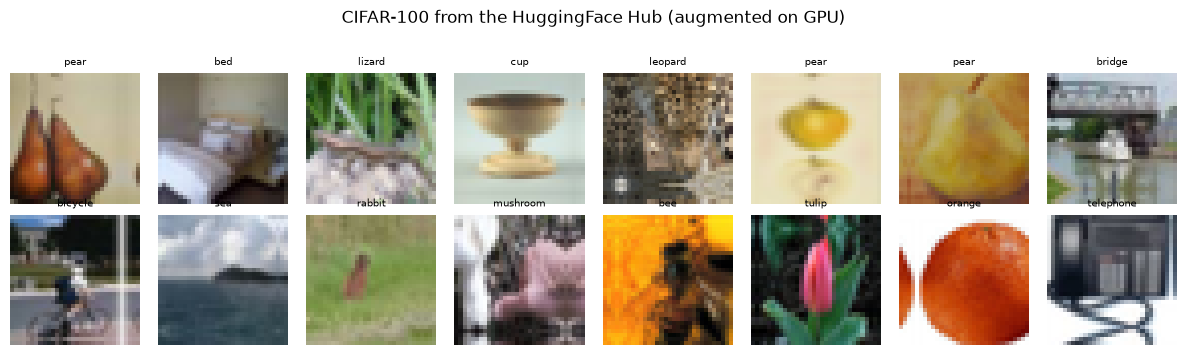

In [6]:
# -- Visualize a batch ------------------------------------------------------------------------------
import matplotlib.pyplot as plt

def denorm(img):
    m, s = torch.tensor(MEAN).view(3, 1, 1), torch.tensor(STD).view(3, 1, 1)
    return (img * s + m).clamp(0, 1).permute(1, 2, 0).numpy()

images, labels = next(iter(train_loader))
images, labels = images.cpu(), labels.cpu()          # batch is device-resident now; plot on CPU
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for i, ax in enumerate(axes.flat):
    ax.imshow(denorm(images[i]))
    ax.set_title(CLASSES[labels[i]][:12], fontsize=7)
    ax.axis('off')
plt.suptitle('CIFAR-100 from the HuggingFace Hub (augmented on GPU)', y=1.03)
plt.tight_layout(); plt.show()

## 3. The models — imported from the ImageNet-32 study, unchanged

Same stem surgery, same patch size, same everything.  The only argument that moves is
`num_classes=100` — exactly the claim the part-1 README makes about porting between CIFAR-10
and ImageNet-32, now demonstrated on a third dataset from a different source.

In [7]:
import models as M          # ../a1-imagenet32/models.py

model = M.build(MODEL, num_classes=NUM_CLASSES).to(DEVICE)
print(f'{MODEL}: {M.n_params(model):,} params')

model.eval()
with torch.no_grad():
    out = model(images.to(DEVICE))
print(f'forward check: {tuple(images.shape)} -> {tuple(out.shape)}  (expected (*, {NUM_CLASSES}))')

resnet18: 11,220,132 params


forward check: (512, 3, 32, 32) -> (512, 100)  (expected (*, 100))


## 4. Train

The loop is the standard part-1 recipe: 5-epoch linear warmup → cosine decay, label smoothing,
AMP on CUDA, gradient clipping, and — for the ViT only — mixup (part 1 measured that giving
mixup to the CNN makes it 7.6 points WORSE, so the CNN doesn't get it).  We report top-1 and
top-5: with 100 classes, top-5 is worth watching.

In [8]:
import time
import torch.nn as nn
from tqdm.auto import tqdm

criterion = nn.CrossEntropyLoss(label_smoothing=RECIPE['label_smooth'])
optimizer = (torch.optim.AdamW(model.parameters(), lr=RECIPE['lr'], weight_decay=RECIPE['wd'])
             if RECIPE['opt'] == 'adamw' else
             torch.optim.SGD(model.parameters(), lr=RECIPE['lr'], momentum=0.9,
                             nesterov=True, weight_decay=RECIPE['wd']))
warm = torch.optim.lr_scheduler.LinearLR(optimizer, 0.01, total_iters=RECIPE['warmup'])
cos = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, EPOCHS - RECIPE['warmup']))
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, [warm, cos], [RECIPE['warmup']])
USE_AMP = DEVICE.type == 'cuda'
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def mixup(x, y, alpha=0.2):
    lam = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[perm], y, y[perm], lam


@torch.no_grad()
def evaluate():
    model.eval()
    c1 = c5 = n = 0
    for x, y in test_loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        _, pred = model(x).topk(5, dim=1)
        hits = pred.eq(y.view(-1, 1))
        c1 += hits[:, :1].any(1).sum().item()
        c5 += hits.any(1).sum().item()
        n += y.size(0)
    return c1 / n, c5 / n


history, best = {'train_loss': [], 'top1': [], 'top5': []}, 0.0
for epoch in range(1, EPOCHS + 1):
    model.train()
    t0, seen = time.time(), 0
    loss_sum = torch.zeros((), device=DEVICE)       # accumulate on-GPU; sync once per epoch
    for x, y in tqdm(train_loader, desc=f'epoch {epoch}/{EPOCHS}', leave=False):
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(DEVICE.type, enabled=USE_AMP):
            if RECIPE['mixup']:
                xm, ya, yb, lam = mixup(x, y)
                out = model(xm)          # one forward, not two (was model(xm) called twice)
                loss = lam * criterion(out, ya) + (1 - lam) * criterion(out, yb)
            else:
                loss = criterion(model(x), y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), RECIPE['clip'])
        scaler.step(optimizer); scaler.update()
        loss_sum += loss.detach() * y.size(0); seen += y.size(0)
    train_loss = (loss_sum / seen).item()           # single host<-device sync for the epoch
    if train_loss != train_loss:                    # NaN guard, straight from part 1's engine
        raise RuntimeError('loss is NaN — the run has diverged (lower the LR)')
    scheduler.step()

    top1, top5 = evaluate()
    best = max(best, top1)
    history['train_loss'].append(train_loss)
    history['top1'].append(top1); history['top5'].append(top5)
    print(f'epoch {epoch:3d}/{EPOCHS}  train loss {train_loss:.3f}  |  '
          f'val top1 {top1:6.2%} top5 {top5:6.2%}  |  '
          f'{time.time()-t0:5.1f}s  {seen/(time.time()-t0):,.0f} img/s')

print(f'\nBest val top-1: {best:.2%}')

C:\Users\truer\AppData\Local\Temp\ipykernel_67528\4092350503.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


epoch 1/40:   0%|          | 0/97 [00:00<?, ?it/s]

epoch   1/40  train loss 4.568  |  val top1  4.14% top5 14.01%  |   20.1s  2,466 img/s


epoch 2/40:   0%|          | 0/97 [00:00<?, ?it/s]

epoch   2/40  train loss 4.175  |  val top1 11.16% top5 32.47%  |    2.6s  18,999 img/s


...

epoch  38/40  train loss 0.850  |  val top1 73.81% top5 92.33%  |    2.7s  18,428 img/s


epoch 39/40:   0%|          | 0/97 [00:00<?, ?it/s]

epoch  39/40  train loss 0.844  |  val top1 73.71% top5 92.44%  |    2.7s  18,401 img/s


epoch 40/40:   0%|          | 0/97 [00:00<?, ?it/s]

epoch  40/40  train loss 0.843  |  val top1 73.77% top5 92.28%  |    2.7s  18,483 img/s

Best val top-1: 73.81%


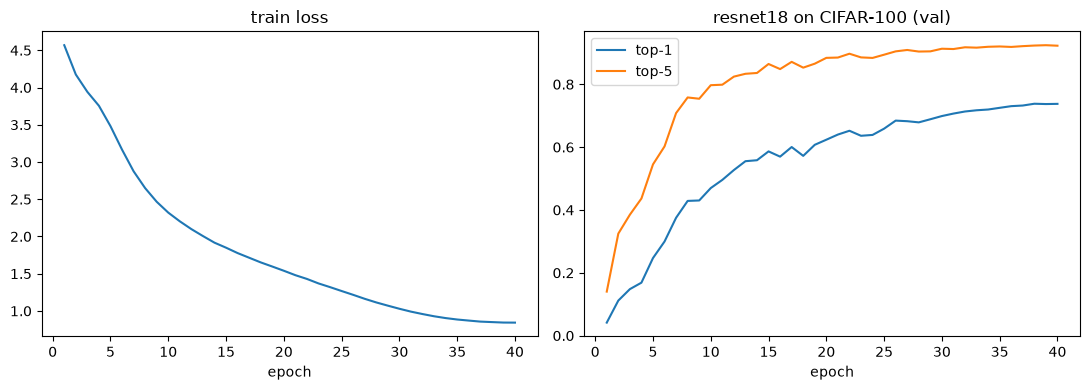

In [9]:
# -- Learning curves --------------------------------------------------------------------------------
xs = range(1, len(history['top1']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(xs, history['train_loss']); ax1.set_title('train loss'); ax1.set_xlabel('epoch')
ax2.plot(xs, history['top1'], label='top-1')
ax2.plot(xs, history['top5'], label='top-5')
ax2.set_title(f'{MODEL} on CIFAR-100 (val)'); ax2.set_xlabel('epoch'); ax2.legend()
plt.tight_layout(); plt.show()

## 5. Where does 500 images/class land in the crossover story?

Fill in your two runs and read the row against part 1's:

| dataset | imgs/class | best CNN | best ViT | gap (CNN − ViT) |
|---|---|---|---|---|
| CIFAR-10 | 5,000 | 92.50% | 73.03% | +19.5 |
| ImageNet-32 | 1,281 | 41.54% | 42.76% | −1.2 |
| **CIFAR-100** | **500** | *your resnet18 run* | *your vit run* | *?* |

Reference points from the literature: a well-tuned ResNet-18 lands around ~76–78% on
CIFAR-100; from-scratch ViTs this size typically trail by 5–15 points at this scale.  If your
gap comes out **wider than CIFAR-10's**, per-class data is what the ViT is starved of — which
matters for part 2, where class counts are a design choice we control.

## 6. What this notebook adds to part 1

- **Goal 3 of the proposal, demonstrated**: a new data source (HuggingFace Hub parquet) feeding
  the existing models through a ~15-line adapter — no changes to `models.py`, no new pipeline.
  This is the acquisition path part 2's datasets will use, whatever they turn out to be.
- **A third point for the crossover analysis**, separating *total data* from *data per class* —
  the two were confounded in part 1's comparison.
- **The part-1 lessons, applied not just cited**: recipe follows architecture, LR scales with
  batch size, mixup only for the transformer, NaN guard in the loop, workers + persistent_workers
  in the loader.